# Semi-Supervised Transfer Learning: 3-Class CTG Classification

Use weights from the binary baseline model to train a 3-class classifier via transfer learning.
- **Freeze → Unfreeze fine-tuning**: Progressive unfreezing of layers during training
- **Data augmentation**: tf.data pipeline with random shifts, noise, and scaling
- **Evaluation**: Confusion matrix, classification report, and transfer vs. from-scratch comparison

## Section 1: Imports, Seeds & Environment Setup

In [80]:
import pandas as pd
import numpy as np
import wfdb
import json
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, GlobalAveragePooling2D, Dense, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    accuracy_score, precision_score, recall_score
)
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Numpy version: {np.__version__}")

TensorFlow version: 2.16.1
Numpy version: 1.26.4


## Section 2: Data Loading & Preprocessing (Same as Baseline)

In [81]:
# Signal preprocessing functions (same as baseline)

def remove_trailing_zeros(signal):
    """Remove trailing zeros from a signal."""
    if not isinstance(signal, list):
        raise ValueError("Input signal must be a list.")
    
    last_non_zero_index = len(signal) - 1
    while last_non_zero_index >= 0 and signal[last_non_zero_index] == 0:
        last_non_zero_index -= 1
    
    return signal[:last_non_zero_index + 1]

def extract_last_30_minutes(signal, sampling_rate=4):
    """Extract last 30 minutes of signal."""
    num_samples_30_minutes = 30 * 60 * sampling_rate
    if len(signal) < num_samples_30_minutes:
        return []
    return signal[-num_samples_30_minutes:]

def downsample_to_1hz(signal, original_fs=4, target_fs=1):
    """Downsample signal to 1 Hz."""
    factor = original_fs // target_fs
    return signal[::factor]

def is_signal_acceptable(signal, threshold=0.16):
    """Check if signal loss is within acceptable threshold."""
    if not signal or len(signal) == 0:
        return False
    total_length = len(signal)
    zero_count = signal.count(0)
    signal_loss = zero_count / total_length
    return signal_loss < threshold

print("Preprocessing functions defined")

Preprocessing functions defined


In [82]:
# Load raw CTG records
raw_dataset = Path("../data/raw_dataset")
records = [p.stem for p in raw_dataset.glob("*.hea")]
print(f"Found {len(records)} CTG records")

# Process all records
processed_records = []

for rec in records:
    record = wfdb.rdrecord(raw_dataset / rec)
    signals = record.p_signal
    
    fhr = signals[:, 0].tolist()
    uc  = signals[:, 1].tolist()
    
    # Apply preprocessing pipeline
    fhr = remove_trailing_zeros(fhr)
    uc  = remove_trailing_zeros(uc)
    fhr = extract_last_30_minutes(fhr, sampling_rate=record.fs)
    uc  = extract_last_30_minutes(uc, sampling_rate=record.fs)
    fhr = downsample_to_1hz(fhr, original_fs=record.fs, target_fs=1)
    uc  = downsample_to_1hz(uc, original_fs=record.fs, target_fs=1)
    
    # Selection
    if is_signal_acceptable(fhr) and is_signal_acceptable(uc):
        processed_records.append({
            "rec_id": rec,
            "FHR": fhr,
            "UC": uc
        })

data_df = pd.DataFrame(processed_records)
print(f"Processed {len(data_df)} records that passed quality criteria")

Found 552 CTG records
Processed 220 records that passed quality criteria


In [83]:
# Load 3-class labels
labels_df = pd.read_csv('../ExpertAnnotations/CTG_Majority_Vote_Labels_FINAL.csv')
print(f"Label columns: {labels_df.columns.tolist()}")
print(f"\nRaw label distribution:")
print(labels_df['Clinical_Label'].value_counts())

Label columns: ['rec_id', 'Majority_Vote_Label', 'Clinical_Label']

Raw label distribution:
Clinical_Label
No Hypoxia (Normal)          426
Mild Hypoxia (Suspicious)    126
Name: count, dtype: int64


In [84]:
# Merge with labels
data_df['rec_id'] = data_df['rec_id'].astype(str)
labels_df['rec_id'] = labels_df['rec_id'].astype(str)

merged_df = data_df.merge(
    labels_df,
    left_on="rec_id",
    right_on="rec_id",
    how="inner"
)

print(f"Merged dataset shape: {merged_df.shape}")
print(f"\nLabel distribution:")
print(merged_df["Clinical_Label"].value_counts())

Merged dataset shape: (220, 5)

Label distribution:
Clinical_Label
No Hypoxia (Normal)          164
Mild Hypoxia (Suspicious)     56
Name: count, dtype: int64


## Section 3: Label Preparation for 3-Class Classification

In [85]:
# Define stable 3-class mapping
# path to majority voting labels
Labels = '..\ExpertAnnotations\step3_labels.csv'

# print number of normal and abnormal deliveries
labels_df = pd.read_csv(Labels)
num_normal = sum(labels_df['Clinical_Label'] == 'No Hypoxia (Normal)')
num_suspicious = sum(labels_df['Clinical_Label'] == 'Mild Hypoxia (Suspicious)')
num_severe = sum(labels_df['Clinical_Label'] == 'Severe Hypoxia (Pathological)')
num_uninterpretable = sum(labels_df['Clinical_Label'] == 'Uninterpretable (Filtered)')
print(f'Number of normal deliveries: {num_normal}')
print(f'Number of suspicious deliveries: {num_suspicious}')
print(f'Number of severe deliveries: {num_severe}')
print(f'Number of uninterpretable deliveries: {num_uninterpretable}')

Number of normal deliveries: 127
Number of suspicious deliveries: 153
Number of severe deliveries: 57
Number of uninterpretable deliveries: 215


In [86]:
'''
Map the labels
'''

# Create a mapping from record ID to clinical label
labels_df = pd.read_csv(Labels)
print(labels_df.columns)

data_df['rec_id'] = data_df['rec_id'].astype(str)
labels_df['rec_id'] = labels_df['rec_id'].astype(str)
merged_df = data_df.merge(
    labels_df,
    left_on="rec_id",
    right_on="rec_id",
    how="inner"
)

print(merged_df.shape)
label_counts = merged_df['Clinical_Label'].value_counts()
print(label_counts)


Index(['rec_id', 'Majority_Vote_Label', 'Clinical_Label'], dtype='object')
(220, 5)
Clinical_Label
Uninterpretable (Filtered)       91
Mild Hypoxia (Suspicious)        57
No Hypoxia (Normal)              42
Severe Hypoxia (Pathological)    30
Name: count, dtype: int64


In [87]:
UNINT = "Uninterpretable (Filtered)"
MAP_3 = {
    "No Hypoxia (Normal)": 0,
    "Mild Hypoxia (Suspicious)": 1,
    "Severe Hypoxia (Pathological)": 2
}

# 1) Build X
X = np.array([
    np.stack([row["FHR"], row["UC"]], axis=0)
    for _, row in merged_df.iterrows()
], dtype=np.float32)[..., np.newaxis]   # (N,2,1800,1)

# 2) Build y_interp (1=interpretable, 0=uninterpretable)
y_interp = (merged_df["Clinical_Label"] != UNINT).astype(int).values.astype(np.int32)

# 3) Build y_sev (0/1/2 for interpretable, -1 for uninterpretable)
def map_sev(lbl):
    if lbl == UNINT:
        return -1
    return MAP_3[lbl]

y_sev = merged_df["Clinical_Label"].apply(map_sev).values.astype(np.int32)

print("X:", X.shape)
print("Severity counts:", dict(zip(*np.unique(y_sev, return_counts=True))))
print("Interp counts:", dict(zip(*np.unique(y_interp, return_counts=True))))


X: (220, 2, 1800, 1)
Severity counts: {-1: 91, 0: 42, 1: 57, 2: 30}
Interp counts: {0: 91, 1: 129}


In [88]:
def normalize_signals(X):
    """Normalize FHR and UC signals independently per sample (z-score)."""
    X_norm = np.zeros_like(X, dtype=np.float32)
    
    for i in range(len(X)):
        # Normalize FHR (channel 0)
        fhr = X[i, 0, :, 0]
        fhr_mean = np.mean(fhr)
        fhr_std = np.std(fhr)
        if fhr_std > 0:
            X_norm[i, 0, :, 0] = (fhr - fhr_mean) / fhr_std
        else:
            X_norm[i, 0, :, 0] = fhr - fhr_mean
        
        # Normalize UC (channel 1)
        uc = X[i, 1, :, 0]
        uc_mean = np.mean(uc)
        uc_std = np.std(uc)
        if uc_std > 0:
            X_norm[i, 1, :, 0] = (uc - uc_mean) / uc_std
        else:
            X_norm[i, 1, :, 0] = uc - uc_mean
    
    return X_norm

print("Normalization function defined")

Normalization function defined


In [89]:
# Filter out uninterpretable samples for 3-class classification
# Use the X and y_sev arrays created in the previous cell

print("="*70)
print("FILTERING FOR 3-CLASS CLASSIFICATION")
print("="*70)

# Get mask for interpretable samples (y_sev != -1)
interpretable_mask = (y_sev != -1)
num_total = len(y_sev)
num_interpretable = interpretable_mask.sum()
num_uninterpretable = num_total - num_interpretable

print(f"Total samples: {num_total}")
print(f"  Interpretable: {num_interpretable} ({100*num_interpretable/num_total:.1f}%)")
print(f"  Uninterpretable: {num_uninterpretable} ({100*num_uninterpretable/num_total:.1f}%)")

# Filter to keep only interpretable samples
X_labeled = X[interpretable_mask]
y_int = y_sev[interpretable_mask]

print(f"\nFiltered to interpretable samples only")
print(f"  X_labeled shape: {X_labeled.shape}")
print(f"Expected shape: (N, 2, 1800, 1)")

# Show class distribution
unique_classes, class_counts = np.unique(y_int, return_counts=True)
print(f"\nClass distribution (interpretable only):")
class_names_map = {0: 'No Hypoxia (Normal)', 1: 'Mild Hypoxia (Suspicious)', 2: 'Severe Hypoxia (Pathological)'}
class_names = [class_names_map[i] for i in sorted(class_names_map.keys())]
for cls, count in zip(unique_classes, class_counts):
    pct = (count / len(y_int)) * 100
    print(f"  Class {cls} [{class_names_map[cls]}]: {count} samples ({pct:.1f}%)")

# Normalize signals
X_labeled = normalize_signals(X_labeled)
print(f"\n Normalized signals")

# Create one-hot labels
y_onehot = to_categorical(y_int, num_classes=3)

print(f"\nCreated labels:")
print(f"  y_int shape: {y_int.shape}")
print(f"  y_onehot shape: {y_onehot.shape}")

# Basic assertions
assert not np.isnan(y_int).any(), "NaN values detected in y_int"
assert not np.isnan(y_onehot).any(), "NaN values detected in y_onehot"
assert set(np.unique(y_int)).issubset({0, 1, 2}), f"Invalid class indices: {np.unique(y_int)}"
assert len(y_int) > 0, "No interpretable samples found"
assert X_labeled.shape[0] == len(y_int), "Mismatch between X and y lengths"

print(f"\nAll assertions passed")
print(f"="*70)

FILTERING FOR 3-CLASS CLASSIFICATION
Total samples: 220
  Interpretable: 129 (58.6%)
  Uninterpretable: 91 (41.4%)

Filtered to interpretable samples only
  X_labeled shape: (129, 2, 1800, 1)
Expected shape: (N, 2, 1800, 1)

Class distribution (interpretable only):
  Class 0 [No Hypoxia (Normal)]: 42 samples (32.6%)
  Class 1 [Mild Hypoxia (Suspicious)]: 57 samples (44.2%)
  Class 2 [Severe Hypoxia (Pathological)]: 30 samples (23.3%)

 Normalized signals

Created labels:
  y_int shape: (129,)
  y_onehot shape: (129, 3)

All assertions passed


## Section 4: Model Architecture (Configurable for 2 or 3 Classes)

In [90]:
def build_ctg_ms_cnn(input_shape=(2, 1800, 1), num_classes=3, dropout_rate=0.25):
    """
    Build CTG Multi-Scale CNN with configurable number of classes.
    
    All layers except the final Dense head will have stable names for weight transfer.
    
    Args:
        input_shape: tuple (channels, time_steps, features)
        num_classes: number of output classes
        dropout_rate: dropout rate for regularization
    
    Returns:
        Keras Model
    """
    inputs = Input(shape=input_shape)

    # --- Stage 1: Temporal filtering ---
    x = Conv2D(filters=4, kernel_size=(1, 3), padding="same", use_bias=False, name="temporal_filter")(inputs)
    x = BatchNormalization(name="bn_stage1")(x)

    # --- Stage 2: Signal interaction ---
    x = DepthwiseConv2D(kernel_size=(2, 1), depth_multiplier=2, use_bias=False, name="signal_interaction")(x)
    x = BatchNormalization(name="bn_stage2")(x)
    x = Activation("relu", name="relu_stage2")(x)
    x = AveragePooling2D(pool_size=(1, 4), name="pool_stage2")(x)
    x = Dropout(dropout_rate, name="drop_stage2")(x)

    # --- Stage 3: Multi-Scale Temporal Feature Extraction ---
    branch_small = SeparableConv2D(filters=8, kernel_size=(1, 3), padding="same", use_bias=False, name="branch_small")(x)
    branch_small = BatchNormalization(name="bn_branch_small")(branch_small)
    branch_small = Activation("relu", name="relu_branch_small")(branch_small)

    branch_medium = SeparableConv2D(filters=8, kernel_size=(1, 7), padding="same", use_bias=False, name="branch_medium")(x)
    branch_medium = BatchNormalization(name="bn_branch_medium")(branch_medium)
    branch_medium = Activation("relu", name="relu_branch_medium")(branch_medium)

    branch_large = SeparableConv2D(filters=8, kernel_size=(1, 15), padding="same", use_bias=False, name="branch_large")(x)
    branch_large = BatchNormalization(name="bn_branch_large")(branch_large)
    branch_large = Activation("relu", name="relu_branch_large")(branch_large)

    # --- Concatenate multi-scale features ---
    x = Concatenate(axis=-1, name="concat_multiscale")([branch_small, branch_medium, branch_large])

    # --- Channel projection ---
    x = Conv2D(filters=8, kernel_size=(1, 1), use_bias=False, name="channel_projection")(x)
    x = BatchNormalization(name="bn_projection")(x)
    x = Activation("relu", name="relu_projection")(x)
    x = AveragePooling2D(pool_size=(1, 4), name="pool_projection")(x)
    x = Dropout(dropout_rate, name="drop_projection")(x)

    # --- Classification head ---
    x = GlobalAveragePooling2D(name="global_pool")(x)
    outputs = Dense(num_classes, activation="softmax", name="clf_head")(x)

    model = Model(inputs, outputs, name=f"CTG-MS-CNN-{num_classes}class")
    return model

print("Model architecture function defined")

Model architecture function defined


## Section 5: Cross-Validation Training Pipeline with Transfer Learning

In [96]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# CV Configuration
CV_N_SPLITS = 5
CV_N_REPEATS = 10
CV_RANDOM_STATE = 42

pretrained_path = Path("pretrained/baseline_binary.weights.h5")
BATCH_SIZE = 8
DROPOUT_RATE = 0.25
INPUT_SHAPE = (2, 1800, 1)

print(f"CV Configuration:")
print(f"  n_splits: {CV_N_SPLITS} | n_repeats: {CV_N_REPEATS} | random_state: {CV_RANDOM_STATE}")
print(f"  Total folds: {CV_N_SPLITS * CV_N_REPEATS}")
print(f"  Batch size: {BATCH_SIZE} | Dropout: {DROPOUT_RATE}")
print(f"  Pretrained weights: {pretrained_path}")

CV Configuration:
  n_splits: 5 | n_repeats: 10 | random_state: 42
  Total folds: 50
  Batch size: 8 | Dropout: 0.25
  Pretrained weights: pretrained\baseline_binary.weights.h5


In [97]:
def freeze_bn_layers(model, freeze_bn=True):
    """
    Freeze or unfreeze BatchNormalization layers while keeping other layers trainability control.
    
    Args:
        model: Keras model
        freeze_bn: bool, if True freeze BN layers, else unfreeze them
    
    Returns:
        None (modifies model in-place)
    """
    for layer in model.layers:
        if isinstance(layer, BatchNormalization):
            layer.trainable = not freeze_bn
        elif freeze_bn:
            # Don't change trainability of non-BN layers here
            pass

def build_model_with_transfer(pretrained_path, num_classes=3):
    """
    Build and initialize a 3-class model with transferred weights from binary model.
    
    Args:
        pretrained_path: Path to binary model weights
        num_classes: Number of output classes (default 3)
    
    Returns:
        Keras model with transferred weights (except head)
    """
    # Build 3-class model
    model = build_ctg_ms_cnn(input_shape=INPUT_SHAPE, num_classes=num_classes, dropout_rate=DROPOUT_RATE)
    
    # Try to load and transfer weights from binary model
    if pretrained_path.exists():
        model_binary = build_ctg_ms_cnn(input_shape=INPUT_SHAPE, num_classes=2, dropout_rate=DROPOUT_RATE)
        model_binary.load_weights(str(pretrained_path))
        
        # Transfer weights (skip head)
        for l_src, l_tgt in zip(model_binary.layers[:-1], model.layers[:-1]):
            if l_src.get_weights():
                try:
                    l_tgt.set_weights(l_src.get_weights())
                except:
                    pass
        del model_binary
    
    return model

print("Helper functions defined: freeze_bn_layers, build_model_with_transfer")


Helper functions defined: freeze_bn_layers, build_model_with_transfer


In [98]:
@tf.function
def augment_batch_padcrop(x):
    """
    Augment batch using pad+crop for time shifts (no wrap-around) + mild noise.
    
    Args:
        x: input tensor (batch, channels, time_steps, features)
    
    Returns:
        augmented tensor
    """
    batch_size = tf.shape(x)[0]
    channels = tf.shape(x)[1]
    time_steps = tf.shape(x)[2]
    features = tf.shape(x)[3]
    
    # Random time shift using pad + crop (no wrap-around)
    max_shift = 30
    shift = tf.random.uniform((), minval=-max_shift, maxval=max_shift, dtype=tf.int32)
    
    # Pad and crop
    if shift >= 0:
        # Pad on left, crop on right
        x = x[:, :, shift:, :]  # Crop left
        pad_width = [[0, 0], [0, 0], [0, shift], [0, 0]]
        x = tf.pad(x, pad_width, mode='CONSTANT', constant_values=0)
    else:
        # Pad on right, crop on left
        shift = -shift
        x = x[:, :, :-shift, :]  # Crop right
        pad_width = [[0, 0], [0, 0], [shift, 0], [0, 0]]
        x = tf.pad(x, pad_width, mode='CONSTANT', constant_values=0)
    
    # Mild Gaussian noise
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01, dtype=tf.float32)
    x = x + noise
    
    return x

def normalize_fold_data(X_train, X_test):
    """
    Normalize train and test data per-channel using train statistics (NO DATA LEAKAGE).
    
    Args:
        X_train: training data (N, 2, 1800, 1)
        X_test: test data (M, 2, 1800, 1)
    
    Returns:
        X_train_norm, X_test_norm (both normalized using train stats)
    """
    X_train_norm = np.zeros_like(X_train, dtype=np.float32)
    X_test_norm = np.zeros_like(X_test, dtype=np.float32)
    
    for ch in range(X_train.shape[1]):
        # Compute statistics on TRAIN only
        ch_data = X_train[:, ch, :, 0]
        ch_mean = np.mean(ch_data)
        ch_std = np.std(ch_data)
        
        # Normalize both train and test using train statistics
        if ch_std > 0:
            X_train_norm[:, ch, :, 0] = (X_train[:, ch, :, 0] - ch_mean) / ch_std
            X_test_norm[:, ch, :, 0] = (X_test[:, ch, :, 0] - ch_mean) / ch_std
        else:
            X_train_norm[:, ch, :, 0] = X_train[:, ch, :, 0] - ch_mean
            X_test_norm[:, ch, :, 0] = X_test[:, ch, :, 0] - ch_mean
    
    return X_train_norm, X_test_norm

print("Augmentation and normalization functions defined")


Augmentation and normalization functions defined


In [99]:
def train_one_fold(X_train, X_test, y_train, y_test, fold_idx, seed=42):
    """
    Train and evaluate model for one CV fold with freeze→unfreeze strategy.
    
    Args:
        X_train, X_test: signal data for fold
        y_train, y_test: integer labels (NOT one-hot)
        fold_idx: fold number for logging
        seed: random seed
    
    Returns:
        dict with predictions, metrics, and details
    """
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed + fold_idx)
    np.random.seed(seed + fold_idx)
    
    # Normalize per-fold using train statistics only (NO DATA LEAKAGE)
    X_train_norm, X_test_norm = normalize_fold_data(X_train, X_test)
    
    # One-hot encode
    y_train_oh = to_categorical(y_train, num_classes=3)
    y_test_oh = to_categorical(y_test, num_classes=3)
    
    # Create tf.data pipelines
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_norm, y_train_oh))
    train_ds = train_ds.shuffle(len(X_train), reshuffle_each_iteration=True)
    train_ds = train_ds.batch(BATCH_SIZE)
    train_ds = train_ds.map(lambda x, y: (augment_batch_padcrop(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
    
    test_ds = tf.data.Dataset.from_tensor_slices((X_test_norm, y_test_oh))
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    # Compute class weights on TRAIN fold only
    classes = np.array([0, 1, 2])
    present_classes = np.unique(y_train)
    class_weights_array = compute_class_weight('balanced', classes=present_classes, y=y_train)
    class_weight = {cls: 1.0 for cls in classes}
    for cls, w in zip(present_classes, class_weights_array):
        class_weight[cls] = w
    
    # Build model with transfer learning
    model = build_model_with_transfer(pretrained_path, num_classes=3)
    
    # === PHASE A: Train head only (backbone frozen, BN frozen) ===
    for layer in model.layers[:-1]:
        layer.trainable = False
    model.layers[-1].trainable = True
    freeze_bn_layers(model, freeze_bn=True)
    
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    
    cb_a = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    lr_a = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    history_a = model.fit(train_ds, validation_data=test_ds, epochs=20, 
                          callbacks=[cb_a, lr_a], class_weight=class_weight, verbose=0)
    
    # === PHASE B: Unfreeze last N conv blocks (NOT BN), lr=1e-4 ===
    num_unfreeze = 10  # Approximate number of conv blocks to unfreeze
    unfrozen = 0
    for layer in reversed(model.layers[:-1]):
        if 'bn' not in layer.name.lower() and unfrozen < num_unfreeze:
            layer.trainable = True
            unfrozen += 1
    
    freeze_bn_layers(model, freeze_bn=True)  # Keep BN frozen
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    
    cb_b = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    lr_b = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    history_b = model.fit(train_ds, validation_data=test_ds, epochs=30, 
                          callbacks=[cb_b, lr_b], class_weight=class_weight, verbose=0)
    
    # === PHASE C: Unfreeze more layers (NOT BN), lr=3e-5 ===
    for layer in model.layers[:-1]:
        if 'bn' not in layer.name.lower():
            layer.trainable = True
    
    freeze_bn_layers(model, freeze_bn=True)  # Keep BN frozen
    model.compile(optimizer=Adam(learning_rate=3e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    
    cb_c = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    lr_c = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    history_c = model.fit(train_ds, validation_data=test_ds, epochs=30, 
                          callbacks=[cb_c, lr_c], class_weight=class_weight, verbose=0)
    
    # === Evaluate ===
    y_pred_probs = model.predict(X_test_norm, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Compute metrics
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    # OvR AUC (if possible)
    try:
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        ovr_auc = roc_auc_score(y_test_bin, y_pred_probs, multi_class='ovr', average='macro')
    except:
        ovr_auc = np.nan
    
    # Per-class metrics
    per_class = {}
    for c in range(3):
        prec = precision_score(y_test, y_pred, labels=[c], average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, labels=[c], average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, labels=[c], average='macro', zero_division=0)
        per_class[c] = {'precision': prec, 'recall': rec, 'f1': f1}
    
    result = {
        'fold_idx': fold_idx,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_probs': y_pred_probs,
        'accuracy': acc,
        'balanced_acc': balanced_acc,
        'macro_f1': macro_f1,
        'ovr_auc': ovr_auc,
        'kappa': kappa,
        'per_class': per_class,
        'cm': confusion_matrix(y_test, y_pred),
        'total_epochs': len(history_a.history['loss']) + len(history_b.history['loss']) + len(history_c.history['loss'])
    }
    
    del model
    return result

print("train_one_fold function defined")


train_one_fold function defined


In [100]:
def run_repeated_stratified_kfold():
    """
    Run RepeatedStratifiedKFold cross-validation on the full dataset.
    
    Returns:
        List of results dicts, one per fold
    """
    cv = RepeatedStratifiedKFold(n_splits=CV_N_SPLITS, n_repeats=CV_N_REPEATS, 
                                 random_state=CV_RANDOM_STATE)
    
    all_results = []
    fold_count = 0
    
    for train_idx, test_idx in cv.split(X_labeled, y_int):
        fold_count += 1
        X_train_fold = X_labeled[train_idx]
        X_test_fold = X_labeled[test_idx]
        y_train_fold = y_int[train_idx]
        y_test_fold = y_int[test_idx]
        
        print(f"\n{'='*70}")
        print(f"Fold {fold_count}/{CV_N_SPLITS * CV_N_REPEATS}")
        print(f"Train: {len(y_train_fold)} | Test: {len(y_test_fold)}")
        print(f"Train classes: {dict(zip(*np.unique(y_train_fold, return_counts=True)))}")
        print(f"Test classes: {dict(zip(*np.unique(y_test_fold, return_counts=True)))}")
        
        result = train_one_fold(X_train_fold, X_test_fold, y_train_fold, y_test_fold, fold_count)
        all_results.append(result)
        
        print(f"Macro F1: {result['macro_f1']:.4f} | Balanced Acc: {result['balanced_acc']:.4f} | "
              f"OvR AUC: {result['ovr_auc']:.4f} | Epochs: {result['total_epochs']}")
    
    return all_results

# ===== RUN CROSS-VALIDATION =====
print(f"\n{'='*70}")
print(f"STARTING REPEATED STRATIFIED K-FOLD CROSS-VALIDATION")
print(f"Total folds: {CV_N_SPLITS * CV_N_REPEATS}")
print(f"{'='*70}")

cv_results = run_repeated_stratified_kfold()

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION COMPLETE: All {len(cv_results)} folds trained")
print(f"{'='*70}")



STARTING REPEATED STRATIFIED K-FOLD CROSS-VALIDATION
Total folds: 50

Fold 1/50
Train: 103 | Test: 26
Train classes: {0: 34, 1: 45, 2: 24}
Test classes: {0: 8, 1: 12, 2: 6}
Macro F1: 0.3837 | Balanced Acc: 0.3889 | OvR AUC: 0.4950 | Epochs: 50

Fold 2/50
Train: 103 | Test: 26
Train classes: {0: 34, 1: 45, 2: 24}
Test classes: {0: 8, 1: 12, 2: 6}
Macro F1: 0.3549 | Balanced Acc: 0.3889 | OvR AUC: 0.5929 | Epochs: 80

Fold 3/50
Train: 103 | Test: 26
Train classes: {0: 33, 1: 46, 2: 24}
Test classes: {0: 9, 1: 11, 2: 6}
Macro F1: 0.5909 | Balanced Acc: 0.5825 | OvR AUC: 0.7409 | Epochs: 42

Fold 4/50
Train: 103 | Test: 26
Train classes: {0: 33, 1: 46, 2: 24}
Test classes: {0: 9, 1: 11, 2: 6}
Macro F1: 0.3264 | Balanced Acc: 0.3249 | OvR AUC: 0.4611 | Epochs: 63

Fold 5/50
Train: 104 | Test: 25
Train classes: {0: 34, 1: 46, 2: 24}
Test classes: {0: 8, 1: 11, 2: 6}
Macro F1: 0.1511 | Balanced Acc: 0.1970 | OvR AUC: 0.3303 | Epochs: 61

Fold 6/50
Train: 103 | Test: 26
Train classes: {0: 34,

## Section 6: Cross-Validation Results and Aggregate Metrics

In [101]:
# Aggregate per-fold metrics
metrics_names = ['accuracy', 'balanced_acc', 'macro_f1', 'ovr_auc', 'kappa']
fold_metrics = {m: [] for m in metrics_names}

for result in cv_results:
    for m in metrics_names:
        fold_metrics[m].append(result[m])

# Compute mean ± std
print(f"\n{'='*70}")
print(f"CROSS-VALIDATION AGGREGATE METRICS (Mean ± Std over {len(cv_results)} folds)")
print(f"{'='*70}")

for metric in metrics_names:
    values = np.array(fold_metrics[metric])
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"{metric:15s}: {mean_val:.4f} ± {std_val:.4f}")

print(f"{'='*70}")



CROSS-VALIDATION AGGREGATE METRICS (Mean ± Std over 50 folds)
accuracy       : 0.3952 ± 0.1021
balanced_acc   : 0.3947 ± 0.1010
macro_f1       : 0.3527 ± 0.1036
ovr_auc        : 0.5705 ± 0.1014
kappa          : 0.0820 ± 0.1433


In [102]:
# Per-fold metrics table
fold_data = []
for i, result in enumerate(cv_results):
    fold_data.append({
        'Fold': i + 1,
        'Accuracy': result['accuracy'],
        'Balanced Acc': result['balanced_acc'],
        'Macro F1': result['macro_f1'],
        'OvR AUC': result['ovr_auc'],
        'Kappa': result['kappa']
    })

fold_df = pd.DataFrame(fold_data)
print(f"\nPER-FOLD METRICS TABLE:")
print(fold_df.to_string(index=False))

# Include summary row
summary_row = {
    'Fold': 'Mean ± Std',
    'Accuracy': f"{fold_df['Accuracy'].mean():.4f} ± {fold_df['Accuracy'].std():.4f}",
    'Balanced Acc': f"{fold_df['Balanced Acc'].mean():.4f} ± {fold_df['Balanced Acc'].std():.4f}",
    'Macro F1': f"{fold_df['Macro F1'].mean():.4f} ± {fold_df['Macro F1'].std():.4f}",
    'OvR AUC': f"{fold_df['OvR AUC'].mean():.4f} ± {fold_df['OvR AUC'].std():.4f}",
    'Kappa': f"{fold_df['Kappa'].mean():.4f} ± {fold_df['Kappa'].std():.4f}"
}

summary_df = pd.DataFrame([summary_row])
print(f"\n{summary_df.to_string(index=False)}")



PER-FOLD METRICS TABLE:
 Fold  Accuracy  Balanced Acc  Macro F1  OvR AUC     Kappa
    1  0.423077      0.388889  0.383684 0.494974  0.071429
    2  0.346154      0.388889  0.354904 0.592857  0.034934
    3  0.615385      0.582492  0.590909 0.740860  0.389671
    4  0.346154      0.324916  0.326414 0.461067  0.002257
    5  0.200000      0.196970  0.151111 0.330266 -0.187648
    6  0.307692      0.347222  0.309127 0.529828  0.016807
    7  0.461538      0.458333  0.416667 0.578042  0.161290
    8  0.538462      0.558923  0.538402 0.634170  0.314286
    9  0.384615      0.343434  0.308802 0.609571  0.034803
   10  0.320000      0.363636  0.302262 0.649785  0.036281
   11  0.230769      0.208333  0.213585 0.422222 -0.160714
   12  0.269231      0.291667  0.294613 0.435384 -0.122727
   13  0.461538      0.505051  0.442915 0.692048  0.236897
   14  0.307692      0.331650  0.305556 0.535042 -0.008621
   15  0.280000      0.280303  0.195767 0.669711 -0.066351
   16  0.384615      0.333333  


AGGREGATED CONFUSION MATRIX (all 50 folds combined)

Rows: True Labels | Columns: Predicted Labels
True/Pred                      | No Hypoxia (Normal)  | Mild Hypoxia (Suspicious) | Severe Hypoxia (Pathological)
----------------------------------------------------------------------------------------------------
No Hypoxia (Normal)            | 189                  | 152                  | 79                  
Mild Hypoxia (Suspicious)      | 194                  | 213                  | 163                 
Severe Hypoxia (Pathological)  | 102                  | 90                   | 108                 


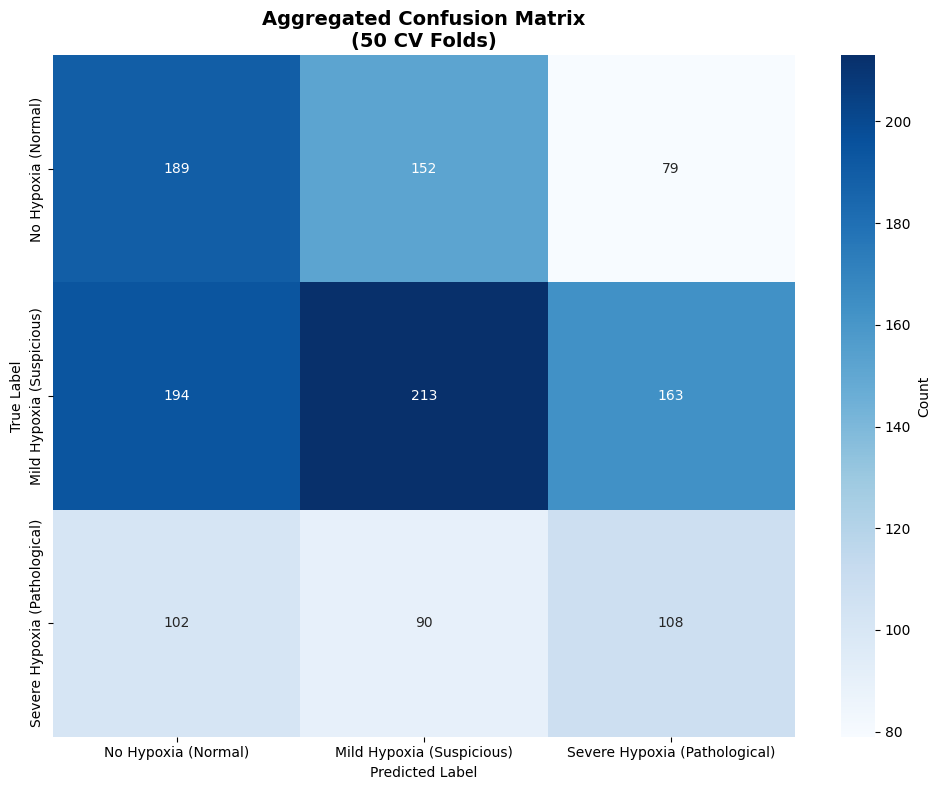

✓ Saved aggregated confusion matrix


In [103]:
# Aggregate confusion matrices across all folds
cm_agg = np.zeros((3, 3), dtype=int)
for result in cv_results:
    cm_agg += result['cm']

print(f"\n{'='*70}")
print(f"AGGREGATED CONFUSION MATRIX (all {len(cv_results)} folds combined)")
print(f"{'='*70}")

class_names_labels = ['No Hypoxia (Normal)', 'Mild Hypoxia (Suspicious)', 'Severe Hypoxia (Pathological)']
print("\nRows: True Labels | Columns: Predicted Labels")
print(f"{'True/Pred':<30s} | {class_names_labels[0]:<20s} | {class_names_labels[1]:<20s} | {class_names_labels[2]:<20s}")
print('-' * 100)
for i, row_name in enumerate(class_names_labels):
    print(f"{row_name:<30s} | {cm_agg[i, 0]:<20d} | {cm_agg[i, 1]:<20d} | {cm_agg[i, 2]:<20d}")

# Plot aggregated confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_agg, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_labels, yticklabels=class_names_labels,
            cbar=True, cbar_kws={'label': 'Count'})
plt.title(f'Aggregated Confusion Matrix\n({len(cv_results)} CV Folds)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('cv_aggregated_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Saved aggregated confusion matrix")


In [104]:
# Per-class metrics: compute averages over folds
per_class_agg = {0: {'precision': [], 'recall': [], 'f1': []},
                 1: {'precision': [], 'recall': [], 'f1': []},
                 2: {'precision': [], 'recall': [], 'f1': []}}

for result in cv_results:
    for cls in range(3):
        per_class_agg[cls]['precision'].append(result['per_class'][cls]['precision'])
        per_class_agg[cls]['recall'].append(result['per_class'][cls]['recall'])
        per_class_agg[cls]['f1'].append(result['per_class'][cls]['f1'])

print(f"\n{'='*70}")
print(f"PER-CLASS METRICS (Mean ± Std over {len(cv_results)} folds)")
print(f"{'='*70}\n")

for cls_idx, cls_name in enumerate(class_names_labels):
    print(f"Class {cls_idx}: {cls_name}")
    
    prec_vals = np.array(per_class_agg[cls_idx]['precision'])
    rec_vals = np.array(per_class_agg[cls_idx]['recall'])
    f1_vals = np.array(per_class_agg[cls_idx]['f1'])
    
    print(f"  Precision: {prec_vals.mean():.4f} ± {prec_vals.std():.4f}")
    print(f"  Recall:    {rec_vals.mean():.4f} ± {rec_vals.std():.4f}")
    print(f"  F1-score:  {f1_vals.mean():.4f} ± {f1_vals.std():.4f}")
    print()

print(f"{'='*70}")



PER-CLASS METRICS (Mean ± Std over 50 folds)

Class 0: No Hypoxia (Normal)
  Precision: 0.4011 ± 0.1483
  Recall:    0.4503 ± 0.2063
  F1-score:  0.4056 ± 0.1514

Class 1: Mild Hypoxia (Suspicious)
  Precision: 0.4534 ± 0.2223
  Recall:    0.3739 ± 0.2563
  F1-score:  0.3729 ± 0.1939

Class 2: Severe Hypoxia (Pathological)
  Precision: 0.3066 ± 0.2872
  Recall:    0.3600 ± 0.3007
  F1-score:  0.2796 ± 0.2047



In [105]:
# Final comprehensive summary
print(f"\n{'='*70}")
print(f"EXPERIMENT SUMMARY: Robust Transfer Learning for 3-Class CTG")
print(f"{'='*70}")

print(f"\n1. DATASET:")
print(f"   Total interpretable samples: {len(X_labeled)}")
print(f"   Input shape: {X_labeled.shape}")
print(f"   Class distribution: {dict(zip(*np.unique(y_int, return_counts=True)))}")

print(f"\n2. CROSS-VALIDATION SETUP:")
print(f"   Method: RepeatedStratifiedKFold")
print(f"   K-folds: {CV_N_SPLITS}")
print(f"   Repeats: {CV_N_REPEATS}")
print(f"   Total folds: {CV_N_SPLITS * CV_N_REPEATS}")

print(f"\n3. TRANSFER LEARNING PIPELINE:")
print(f"   Binary backbone: {pretrained_path}")
print(f"   Head replacement: Dense(2) → Dense(3, softmax)")
print(f"   Input shape: {INPUT_SHAPE}")

print(f"\n4. TRAINING PHASES (per fold):")
print(f"   Phase A: Backbone frozen (except BN), Head only, lr=1e-3, 20 epochs max, early stop on val_loss")
print(f"   Phase B: Last ~10 conv blocks (NOT BN), lr=1e-4, 30 epochs max, early stop on val_loss")
print(f"   Phase C: All conv layers (NOT BN), lr=3e-5, 30 epochs max, early stop on val_loss")
print(f"   Note: BN layers ALWAYS frozen to preserve batch statistics from pretraining")

print(f"\n5. DATA HANDLING:")
print(f"   - Per-fold normalization: z-score using TRAIN fold statistics only (NO data leakage)")
print(f"   - Data augmentation:")
print(f"     • Time shift: pad+crop ±30 samples (no wrap-around)")
print(f"     • Gaussian noise: σ=0.01")
print(f"   - Class weights: computed per TRAIN fold only (balanced strategy)")

print(f"\n6. EVALUATION METRICS:")
print(f"   - Accuracy, Balanced Accuracy, Macro F1-score")
print(f"   - OvR AUC, Cohen's Kappa")
print(f"   - Per-class Precision, Recall, F1")
print(f"   - Aggregated Confusion Matrix")

print(f"\n7. AGGREGATE RESULTS (Mean ± Std):")
for metric in metrics_names:
    values = np.array(fold_metrics[metric])
    mean_val = np.mean(values)
    std_val = np.std(values)
    print(f"   {metric:15s}: {mean_val:.4f} ± {std_val:.4f}")

print(f"\n{'='*70}")
print(f"Completed: {datetime.now().isoformat()}")
print(f"{'='*70}")



EXPERIMENT SUMMARY: Robust Transfer Learning for 3-Class CTG

1. DATASET:
   Total interpretable samples: 129
   Input shape: (129, 2, 1800, 1)
   Class distribution: {0: 42, 1: 57, 2: 30}

2. CROSS-VALIDATION SETUP:
   Method: RepeatedStratifiedKFold
   K-folds: 5
   Repeats: 10
   Total folds: 50

3. TRANSFER LEARNING PIPELINE:
   Binary backbone: pretrained\baseline_binary.weights.h5
   Head replacement: Dense(2) → Dense(3, softmax)
   Input shape: (2, 1800, 1)

4. TRAINING PHASES (per fold):
   Phase A: Backbone frozen (except BN), Head only, lr=1e-3, 20 epochs max, early stop on val_loss
   Phase B: Last ~10 conv blocks (NOT BN), lr=1e-4, 30 epochs max, early stop on val_loss
   Phase C: All conv layers (NOT BN), lr=3e-5, 30 epochs max, early stop on val_loss
   Note: BN layers ALWAYS frozen to preserve batch statistics from pretraining

5. DATA HANDLING:
   - Per-fold normalization: z-score using TRAIN fold statistics only (NO data leakage)
   - Data augmentation:
     • Time sh